# transfer learning: frozen features vs fine-tuning

the from-scratch CNN learned every filter from ~15k small galaxy images and got to a test
macro-F1 of ~0.53. transfer learning asks whether a ResNet-18 already trained on ImageNet
can do better by reusing what it knows about edges, blobs and textures.

there are two ways to do it, and the difference between them turns out to be the whole
lesson of this notebook:

1. **frozen feature extraction** — freeze the entire ImageNet backbone, train only a new
   classifier head. cheap and fast, but the features are stuck as-is.
2. **fine-tuning** — start from the ImageNet weights but let the whole network keep
   training at a low learning rate, so the features *adapt* to galaxies.

we run both and compare them against the baseline. the numbers below are the real trained
runs, read back from MLflow.

In [1]:
import sys, json
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread

from galaxy_cnn.model import build_model, count_params

for kind in ["resnet", "resnet_ft"]:
    total, trainable = count_params(build_model(kind))
    tag = "frozen backbone" if kind == "resnet" else "fine-tuned (all trainable)"
    print(f"{kind:10s} {tag:28s} {trainable:>11,} / {total:,} trainable")

resnet     frozen backbone                    5,130 / 11,181,642 trainable


resnet_ft  fine-tuned (all trainable)    11,181,642 / 11,181,642 trainable


the frozen model trains ~5k parameters (just the head); the fine-tuned model trains all
~11M. both feed the galaxies in at 96px with **ImageNet** normalisation — that's the pixel
distribution the pre-trained filters expect. the only knob that differs is whether the
backbone is allowed to move, and the fine-tune run uses a deliberately low learning rate
(3e-4) so it nudges the pre-trained weights rather than blowing them away.

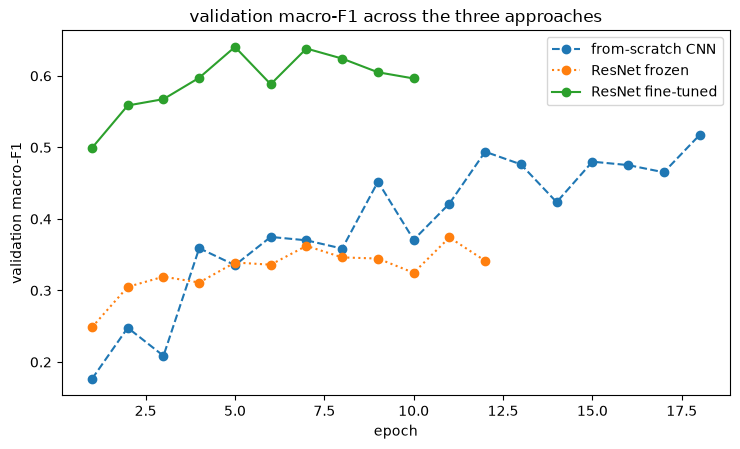

In [2]:
# real validation curves for all three runs, from the MLflow store
import mlflow
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name("galaxy10-morphology")
runs = client.search_runs(exp.experiment_id, order_by=["attributes.start_time ASC"])
by_name = {r.data.tags.get("mlflow.runName"): r for r in runs}

def history(run_id, key):
    h = sorted(client.get_metric_history(run_id, key), key=lambda m: m.step)
    return [m.step for m in h], [m.value for m in h]

fig, ax = plt.subplots(figsize=(7.5, 4.6))
styles = {"small": ("--", "from-scratch CNN"),
          "resnet": (":", "ResNet frozen"),
          "resnet_ft": ("-", "ResNet fine-tuned")}
for name, (ls, lab) in styles.items():
    s, v = history(by_name[name].info.run_id, "val_macro_f1")
    ax.plot(s, v, ls, marker="o", label=lab)
ax.set_xlabel("epoch"); ax.set_ylabel("validation macro-F1")
ax.set_title("validation macro-F1 across the three approaches")
ax.legend()
plt.tight_layout()

## head to head on the test set

In [3]:
rows = []
for name, (_, lab) in styles.items():
    m = by_name[name].data.metrics
    rows.append({
        "approach": lab,
        "trainable params": int(by_name[name].data.params["params_trainable"]),
        "test accuracy": round(m["test_accuracy"], 3),
        "test macro-F1": round(m["test_macro_f1"], 3),
    })
comp = pd.DataFrame(rows).set_index("approach")
comp

,trainable params,test accuracy,test macro-F1
approach,,,
from-scratch CNN,305706,0.653,0.534
ResNet frozen,5130,0.473,0.384
ResNet fine-tuned,11181642,0.797,0.641


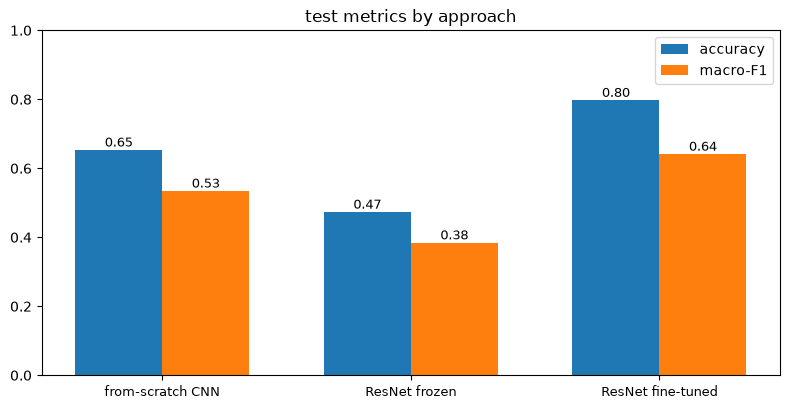

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(comp)); w = 0.35
ax.bar(x - w/2, comp["test accuracy"], w, label="accuracy")
ax.bar(x + w/2, comp["test macro-F1"], w, label="macro-F1")
ax.set_xticks(x); ax.set_xticklabels(comp.index, fontsize=9)
ax.set_ylim(0, 1); ax.legend(); ax.set_title("test metrics by approach")
for i, (a, f) in enumerate(zip(comp["test accuracy"], comp["test macro-F1"])):
    ax.text(i - w/2, a + 0.01, f"{a:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, f + 0.01, f"{f:.2f}", ha="center", fontsize=9)
plt.tight_layout()

two results jump out:

- **frozen features are the *worst* of the three** — worse even than the small from-scratch
  net. that's the domain gap talking: ImageNet's filters are tuned for everyday photos, and
  frozen at 96px they just aren't a great description of a smudgy galaxy. reusing them without
  adapting them doesn't pay off here.
- **fine-tuning is the clear winner.** letting those same ImageNet weights keep training on
  galaxies lifts test macro-F1 from 0.53 (scratch) and 0.38 (frozen) up to ~0.64, and accuracy
  to ~0.80 — the best of the lot, and competitive with published Galaxy10 baselines.

the takeaway is the practical rule of thumb for transfer learning: a good initialisation (the
ImageNet weights) plus adaptation (fine-tuning) beats both training from scratch and using
frozen features off the shelf.

## where the win comes from

comparing the confusion matrices of the baseline and the fine-tuned model shows the gain
isn't uniform — it's concentrated in the big smooth/spiral classes that now get cleanly
separated.

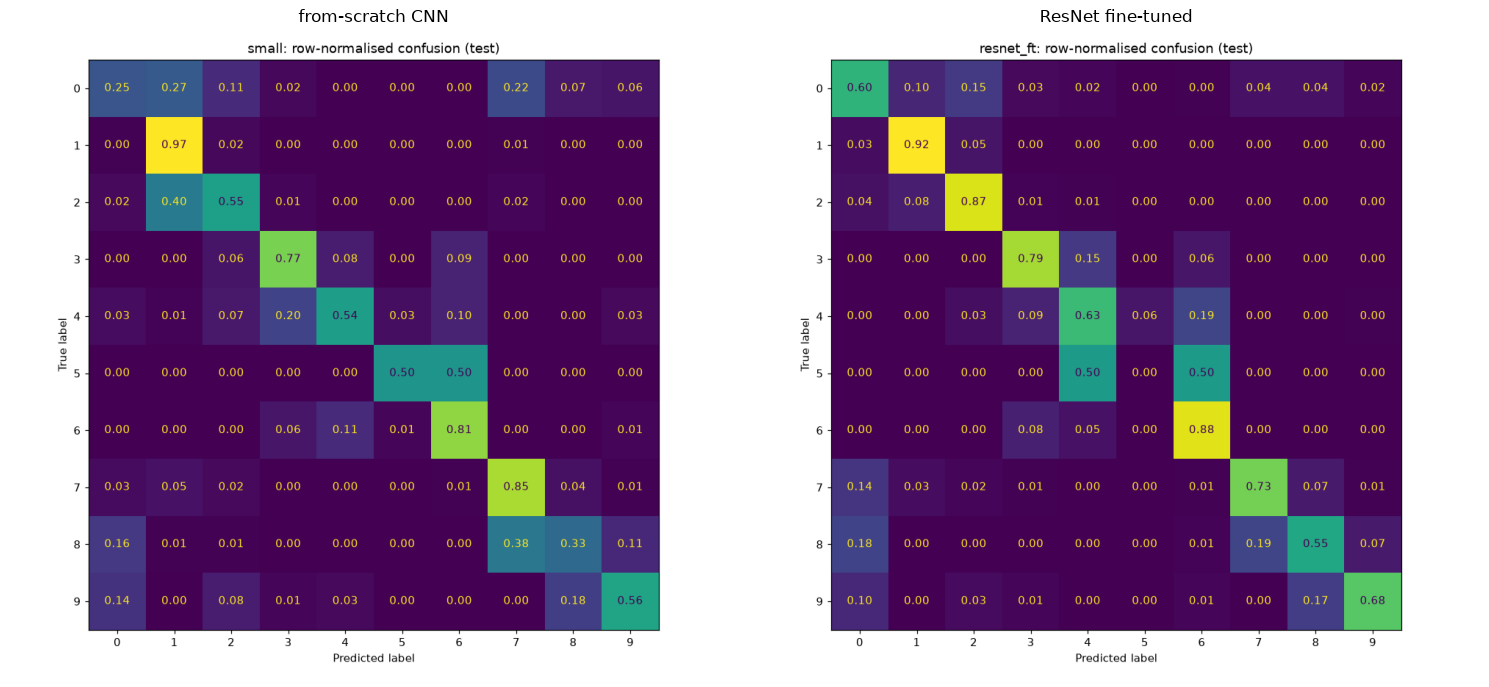

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
for a, name, title in zip(ax, ["small", "resnet_ft"],
                          ["from-scratch CNN", "ResNet fine-tuned"]):
    a.imshow(imread(f"../reports/{name}_confusion.png"))
    a.axis("off"); a.set_title(title)
plt.tight_layout()

In [6]:
# per-class F1: baseline vs champion
small_r = json.load(open("../reports/small_report.json"))
ft_r = json.load(open("../reports/resnet_ft_report.json"))
from galaxy_cnn.data import CLASS_NAMES
print(f"{'class':38s} {'scratch':>8s} {'fine-tuned':>11s} {'n':>5s}")
for name in CLASS_NAMES:
    print(f"{name:38s} {small_r[name]['f1-score']:8.2f} "
          f"{ft_r[name]['f1-score']:11.2f} {int(ft_r[name]['support']):5d}")

class                                   scratch  fine-tuned     n
Disk, Face-on, No Spiral                   0.37        0.65   519
Smooth, Completely round                   0.78        0.90  1050
Smooth, in-between round                   0.66        0.86   944
Smooth, Cigar shaped                       0.48        0.58    53
Disk, Edge-on, Rounded Bulge               0.67        0.72   230
Disk, Edge-on, Boxy Bulge                  0.17        0.00     2
Disk, Edge-on, No Bulge                    0.76        0.71    88
Disk, Face-on, Tight Spiral                0.57        0.72   168
Disk, Face-on, Medium Spiral               0.38        0.58   136
Disk, Face-on, Loose Spiral                0.50        0.71    78


fine-tuning improves almost every class, and dramatically so on the common ones (the two
"smooth" classes go to ~0.86-0.90 F1). the one class it can't rescue is "Disk, Edge-on, Boxy
Bulge" — with only a couple of test examples (17 in the whole dataset) there simply isn't
enough signal for *any* method, and honest reporting means saying so rather than hiding it in
an accuracy average.

**conclusion:** the champion model for this project is the **fine-tuned ResNet-18** — test
accuracy ~0.80, macro-F1 ~0.64 — and it's the checkpoint the serving API loads.

**in the real project:** `src/galaxy_cnn/model.py` (`build_resnet(freeze=...)` and the
`resnet` / `resnet_ft` kinds), trained via `python -m galaxy_cnn.train --model resnet_ft`.

**try it yourself:** the middle ground is *partial* fine-tuning — unfreeze only `layer4` and
the head, leaving the early filters fixed. it trains far fewer parameters than full
fine-tuning and often recovers most of the gain, which matters a lot when you're not on a
laptop CPU.